# Mạng Nơ-ron Hồi quy (RNN)

## 1. Giới thiệu về RNN

RNN là một loại mạng nơ-ron nhân tạo được thiết kế để xử lý *dữ liệu tuần tự* (sequential data), như chuỗi thời gian, văn bản, hoặc âm thanh. Điểm đặc biệt của RNN là khả năng "ghi nhớ" thông tin từ các bước trước đó nhờ cấu trúc vòng lặp.

### Tại sao cần RNN?

- Trong mạng nơ-ron truyền thống, mỗi đầu vào là độc lập, không có mối quan hệ với các đầu vào trước đó.
- Với RNN, thông tin từ bước trước được truyền sang bước hiện tại, cho phép học các mẫu trong chuỗi dữ liệu.

### Ứng dụng của RNN

- Dự đoán chuỗi thời gian (ví dụ: giá cổ phiếu).
- Xử lý ngôn ngữ tự nhiên (NLP): dịch máy, sinh văn bản.
- Nhận diện giọng nói.

## 2. Cấu trúc của RNN

RNN có một vòng lặp trong kiến trúc, cho phép trạng thái ẩn (hidden state) được cập nhật qua từng bước thời gian. Các thành phần cơ bản:

- **Đầu vào:** $x_t$ tại thời điểm $t$.
- **Trạng thái ẩn:** $h_t$, lưu trữ thông tin từ các bước trước.
- **Đầu ra:** $y_t$ tại thời điểm $t$.

### Sơ đồ cơ bản

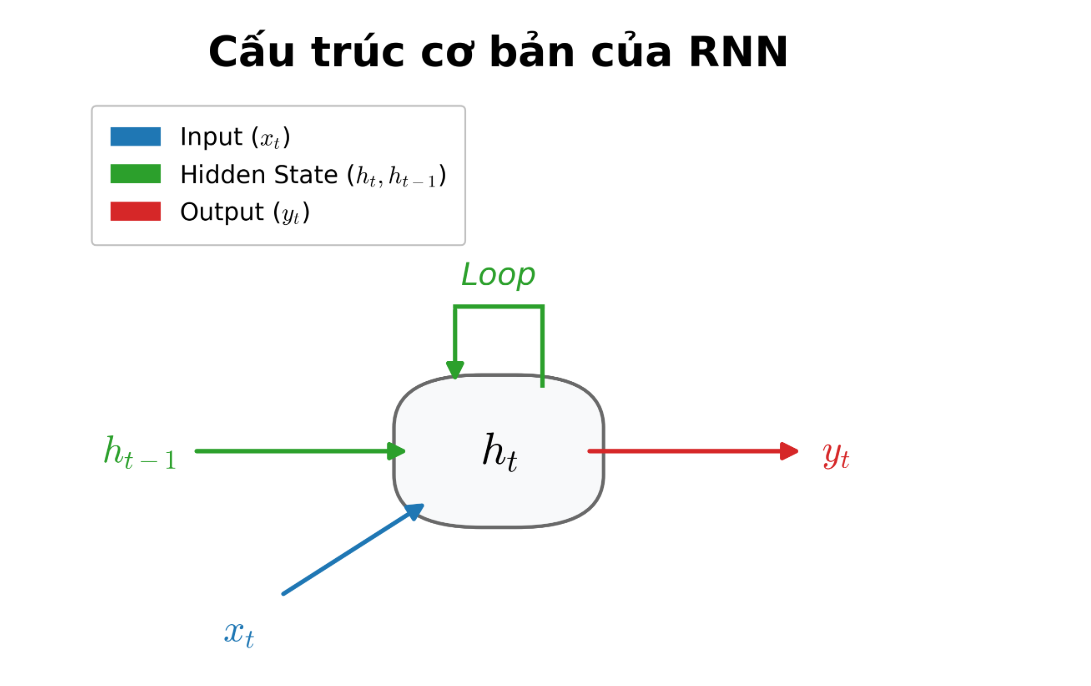


## 3. Công thức toán học của RNN

Trong RNN, tại mỗi thời điểm $t$, mô hình nhận đầu vào $x_t$, kết hợp với trạng thái ẩn từ bước trước $h_{t-1}$, rồi tạo ra trạng thái ẩn mới $h_t$. Từ trạng thái ẩn này, mô hình tiếp tục tính đầu ra $y_t$.

### 3.1. Công thức tính trạng thái ẩn

Trạng thái ẩn tại thời điểm $t$ được tính theo công thức:

$$
h_t = f(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
$$

Trong đó:
- $x_t$: vector đầu vào tại thời điểm $t$
- $h_{t-1}$: trạng thái ẩn tại thời điểm trước đó
- $W_{xh}$: ma trận trọng số từ đầu vào đến trạng thái ẩn
- $W_{hh}$: ma trận trọng số hồi quy giữa trạng thái ẩn trước và trạng thái ẩn hiện tại
- $b_h$: vector bias của tầng ẩn
- $f$: hàm kích hoạt phi tuyến, thường là $\tanh$ hoặc sigmoid

Công thức trên cho thấy trạng thái ẩn mới được hình thành từ hai nguồn thông tin:
- thông tin hiện tại từ đầu vào $x_t$
- thông tin quá khứ được lưu trong trạng thái ẩn $h_{t-1}$

Nhờ cơ chế này, RNN có thể mô hình hóa dữ liệu tuần tự và duy trì ngữ cảnh theo thời gian.

#### Ví dụ minh họa

Giả sử:

$$
x_t = [0.5,\ 0.1]^T
$$

$$
h_{t-1} = [0.2,\ 0.3]^T
$$

và các tham số:

$$
W_{xh} =
\begin{bmatrix}
0.1 & 0.2 \\
0.3 & 0.4
\end{bmatrix}
$$

$$
W_{hh} =
\begin{bmatrix}
0.5 & 0.6 \\
0.7 & 0.8
\end{bmatrix}
$$

$$
b_h = [0.1,\ 0.2]^T
$$

Giả sử hàm kích hoạt là:

$$
f = \tanh
$$

Ta tính lần lượt:

**Bước 1: Thành phần từ đầu vào**

$$
W_{xh}x_t =
\begin{bmatrix}
0.1 & 0.2 \\
0.3 & 0.4
\end{bmatrix}
\begin{bmatrix}
0.5 \\
0.1
\end{bmatrix}
=
\begin{bmatrix}
0.1 \times 0.5 + 0.2 \times 0.1 \\
0.3 \times 0.5 + 0.4 \times 0.1
\end{bmatrix}
=
\begin{bmatrix}
0.07 \\
0.19
\end{bmatrix}
$$

**Bước 2: Thành phần từ trạng thái trước**

$$
W_{hh}h_{t-1} =
\begin{bmatrix}
0.5 & 0.6 \\
0.7 & 0.8
\end{bmatrix}
\begin{bmatrix}
0.2 \\
0.3
\end{bmatrix}
=
\begin{bmatrix}
0.5 \times 0.2 + 0.6 \times 0.3 \\
0.7 \times 0.2 + 0.8 \times 0.3
\end{bmatrix}
=
\begin{bmatrix}
0.28 \\
0.38
\end{bmatrix}
$$

**Bước 3: Cộng với bias**

$$
W_{xh}x_t + W_{hh}h_{t-1} + b_h
=
\begin{bmatrix}
0.07 \\
0.19
\end{bmatrix}
+
\begin{bmatrix}
0.28 \\
0.38
\end{bmatrix}
+
\begin{bmatrix}
0.1 \\
0.2
\end{bmatrix}
=
\begin{bmatrix}
0.45 \\
0.77
\end{bmatrix}
$$

**Bước 4: Áp dụng hàm $\tanh$**

$$
h_t = \tanh([0.45,\ 0.77]^T) \approx [0.422,\ 0.646]^T
$$

Vậy trạng thái ẩn tại thời điểm $t$ là:

$$
h_t \approx [0.422,\ 0.646]^T
$$

### 3.2. Công thức tính đầu ra

Sau khi có trạng thái ẩn $h_t$, đầu ra tại thời điểm $t$ được tính theo công thức:

$$
y_t = g(W_{hy}h_t + b_y)
$$

Trong đó:
- $W_{hy}$: ma trận trọng số từ trạng thái ẩn đến đầu ra
- $b_y$: bias của tầng đầu ra
- $g$: hàm kích hoạt đầu ra

Tùy bài toán, hàm $g$ có thể khác nhau:
- dùng sigmoid cho phân loại nhị phân
- dùng softmax cho phân loại nhiều lớp
- hoặc không dùng hàm kích hoạt nếu là bài toán hồi quy

#### Ví dụ tiếp nối

Giả sử:

$$
h_t = [0.422,\ 0.646]^T
$$

$$
W_{hy} = [0.9,\ 0.8]
$$

$$
b_y = 0.05
$$

và hàm kích hoạt đầu ra là sigmoid:

$$
g = \sigma
$$

Ta tính:

**Bước 1: Nhân trọng số với trạng thái ẩn**

$$
W_{hy}h_t = [0.9,\ 0.8]
\begin{bmatrix}
0.422 \\
0.646
\end{bmatrix}
= 0.9 \times 0.422 + 0.8 \times 0.646
= 0.3798 + 0.5168
= 0.8966
$$

**Bước 2: Cộng bias**

$$
0.8966 + 0.05 = 0.9466
$$

**Bước 3: Áp dụng hàm sigmoid**

$$
y_t = \sigma(0.9466) = \frac{1}{1 + e^{-0.9466}} \approx 0.720
$$

Vậy đầu ra của mô hình tại thời điểm $t$ là:

$$
y_t \approx 0.72
$$

### 3.3. Ý nghĩa của quá trình tính toán

Từ hai công thức trên, có thể thấy rằng RNN hoạt động theo cơ chế lặp qua từng bước thời gian:
1. nhận đầu vào mới $x_t$
2. kết hợp với thông tin đã lưu trong $h_{t-1}$
3. tạo ra trạng thái mới $h_t$
4. sinh đầu ra $y_t$

Nhờ đó, mô hình không chỉ dựa vào dữ liệu hiện tại mà còn tận dụng được ngữ cảnh từ các bước trước trong chuỗi. Đây là đặc điểm cốt lõi giúp RNN phù hợp với các bài toán xử lý dữ liệu tuần tự như văn bản, âm thanh và chuỗi thời gian.

## 4. Huấn luyện RNN (Backpropagation Through Time - BPTT)

RNN được huấn luyện bằng thuật toán **lan truyền ngược qua thời gian** (*Backpropagation Through Time - BPTT*).  
Ý tưởng chính là "mở" mạng RNN theo từng bước thời gian, sau đó áp dụng lan truyền ngược tương tự như trong mạng nơ-ron truyền thống, nhưng trên toàn bộ chuỗi.

Giả sử chuỗi có độ dài $T$, tổng hàm mất mát được tính như sau:

$$
L = \sum_{t=1}^{T} L_t
$$

Trong đó:
- $L_t$ là mất mát tại thời điểm $t$
- $T$ là số bước thời gian của chuỗi

Do trạng thái ẩn tại thời điểm hiện tại phụ thuộc vào các trạng thái trước đó, nên khi tính gradient, sai số không chỉ ảnh hưởng đến một thời điểm riêng lẻ mà còn lan truyền ngược qua nhiều bước thời gian trước đó. Vì vậy, quá trình huấn luyện RNN phức tạp hơn so với mạng nơ-ron truyền thẳng thông thường.

Về mặt trực quan, gradient đối với ma trận trọng số hồi quy $W_{hh}$ có thể được biểu diễn như sau:

$$
\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^{T} \frac{\partial L_t}{\partial W_{hh}}
$$

Điều này cho thấy trọng số $W_{hh}$ được chia sẻ qua tất cả các bước thời gian, nên gradient cuối cùng là tổng đóng góp từ toàn bộ chuỗi.

### Vấn đề gradient biến mất và gradient bùng nổ

Trong thực tế, RNN thường gặp hai vấn đề quan trọng khi huấn luyện trên chuỗi dài:

- **Gradient biến mất (vanishing gradient):** gradient trở nên rất nhỏ sau nhiều lần lan truyền ngược, làm mô hình khó học được các phụ thuộc dài hạn
- **Gradient bùng nổ (exploding gradient):** gradient tăng quá lớn, gây mất ổn định trong quá trình cập nhật trọng số

Đặc biệt, hiện tượng **gradient biến mất** là một trong những hạn chế lớn nhất của RNN cơ bản. Khi chuỗi đầu vào quá dài, thông tin từ các bước đầu chuỗi thường bị suy giảm đáng kể trước khi đến được các bước sau, khiến mô hình khó ghi nhớ ngữ cảnh xa.

Vì lý do đó, các kiến trúc như **LSTM** và **GRU** đã được đề xuất để cải thiện khả năng ghi nhớ thông tin dài hạn và giảm ảnh hưởng của hiện tượng gradient biến mất.

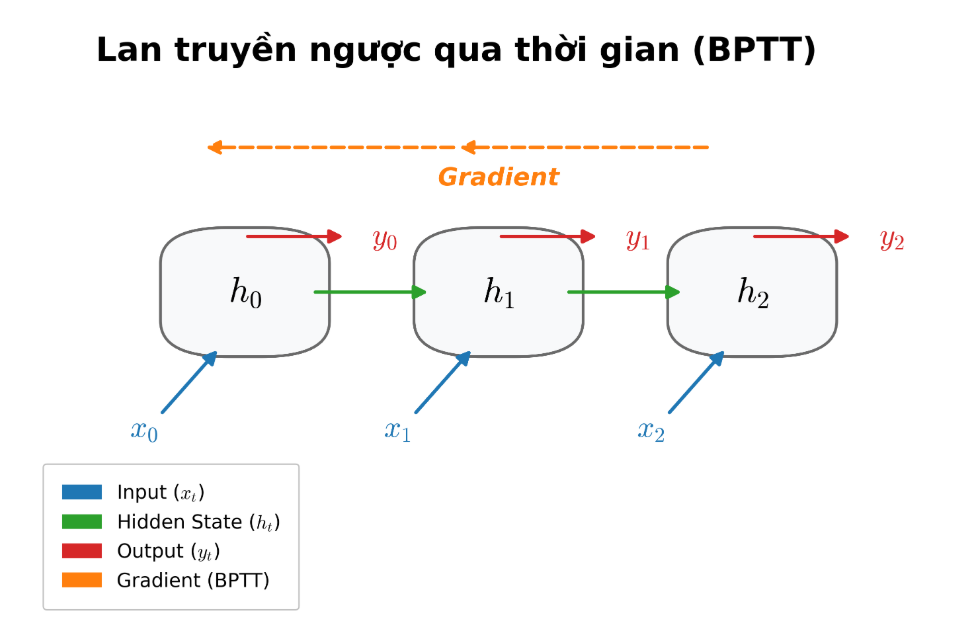

## 5. Ví dụ

Để dễ hình dung cách hoạt động của RNN, ta xét một ví dụ đơn giản trong bài toán dự đoán từ tiếp theo.

Giả sử chuỗi đầu vào là:

**"Tôi" $\rightarrow$ "thích"**

Mục tiêu của mô hình là dự đoán từ tiếp theo sau chuỗi này.  
Giả sử từ điển chỉ gồm ba từ:

- Tôi: $[1,0,0]$
- thích: $[0,1,0]$
- học: $[0,0,1]$

Tại bước thời gian thứ nhất, mô hình nhận từ **"Tôi"** dưới dạng vector one-hot $[1,0,0]$.  
Tại bước thời gian thứ hai, mô hình nhận từ **"thích"** dưới dạng vector $[0,1,0]$.  
Sau khi cập nhật trạng thái ẩn qua hai bước thời gian, RNN tạo ra đầu ra tại bước thứ hai để dự đoán từ tiếp theo.

Giả sử đầu ra của mô hình tại thời điểm đó là:

$$
y_2 = [0.1, 0.2, 0.7]
$$

Vector này có thể được hiểu là xác suất dự đoán cho ba từ trong từ điển.  
Trong đó:
- xác suất từ **"Tôi"** là $0.1$
- xác suất từ **"thích"** là $0.2$
- xác suất từ **"học"** là $0.7$

Vì giá trị lớn nhất nằm ở vị trí của từ **"học"**, nên mô hình dự đoán từ tiếp theo là:

$$
\text{"học"}
$$

Ví dụ này cho thấy RNN không xử lý từng từ một cách độc lập, mà sử dụng thông tin từ các bước trước đó để đưa ra dự đoán ở bước hiện tại. Đây chính là điểm khác biệt quan trọng giữa RNN và mạng nơ-ron truyền thẳng thông thường.

## 6. So sánh RNN và Feedforward Neural Network

| **RNN**                | **Feedforward NN**     |
|------------------------|------------------------|
| Xử lý dữ liệu tuần tự  | Đầu vào độc lập        |
| Có trạng thái ẩn $h_t$ | Không có bộ nhớ        |

## 7. Gradient biến mất

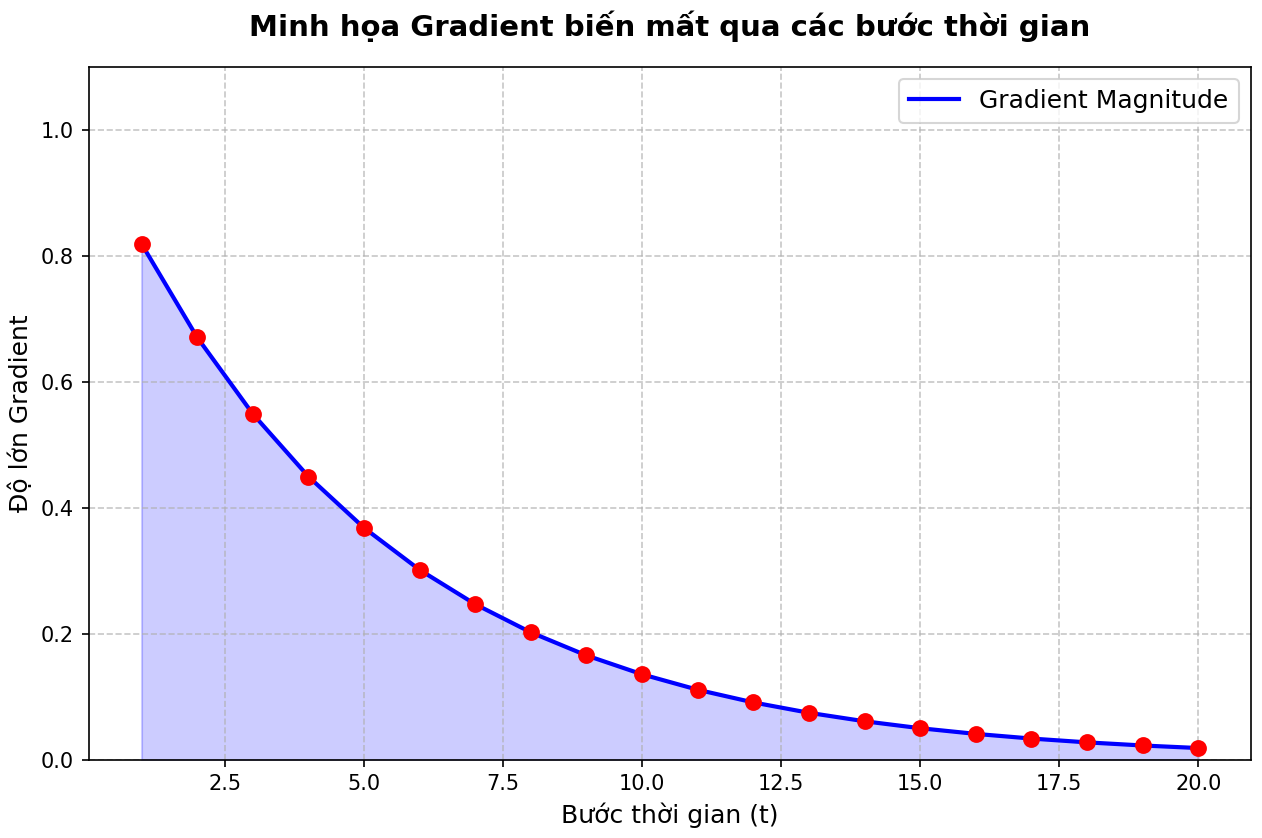


# BÀI THỰC HÀNH CƠ BẢN VỚI RNN

In [13]:
# Import các thư viện cần thiết
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [14]:
# 1. Chuẩn bị dữ liệu
# dữ liệu sin wave 
time_steps = 100
x = np.linspace(0, 20, time_steps)
data = np.sin(x) + 0.1 * np.random.randn(time_steps)

# Chuẩn hóa dữ liệu về khoảng [0, 1]
data = (data - data.min()) / (data.max() - data.min())

# Chuyển thành tensor PyTorch và thêm chiều batch
data = torch.FloatTensor(data).unsqueeze(1)  # Shape: [100, 1]

# Hàm tạo chuỗi con cho huấn luyện
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return torch.stack(X), torch.stack(y)

seq_length = 10  # Độ dài mỗi chuỗi
X, y = create_sequences(data, seq_length)  # X: [90, 10, 1], y: [90, 1]

In [15]:

# Chia 80% tập huấn luyện và 20% kiểm tra
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [16]:
# 2. Xây dựng mô hình RNN
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out[:, -1, :])  # Lấy đầu ra của bước cuối cùng
        return out, hidden
    
    def init_hidden(self, batch_size):
        return torch.zeros(1, batch_size, self.hidden_size)

In [17]:
# Khởi tạo mô hình
model = RNN(input_size=1, hidden_size=20, output_size=1)

In [18]:
# 3. Định nghĩa hàm mất mát và tối ưu hóa
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [19]:
# 4. Huấn luyện mô hình
num_epochs = 100
batch_size = 16
loss_history = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    hidden = model.init_hidden(batch_size)
    
    # Tạo các batch ngẫu nhiên
    indices = torch.randperm(len(X_train))[:batch_size]
    X_batch = X_train[indices]
    y_batch = y_train[indices]
    
    hidden = model.init_hidden(batch_size)
    
    output, hidden = model(X_batch, hidden)
    loss = criterion(output, y_batch)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    total_loss += loss.item()
    loss_history.append(total_loss)  # Lưu loss
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}')

Epoch [10/100], Loss: 0.0554
Epoch [20/100], Loss: 0.0112
Epoch [30/100], Loss: 0.0051
Epoch [40/100], Loss: 0.0073
Epoch [50/100], Loss: 0.0036
Epoch [60/100], Loss: 0.0028
Epoch [70/100], Loss: 0.0025
Epoch [80/100], Loss: 0.0036
Epoch [90/100], Loss: 0.0027
Epoch [100/100], Loss: 0.0031


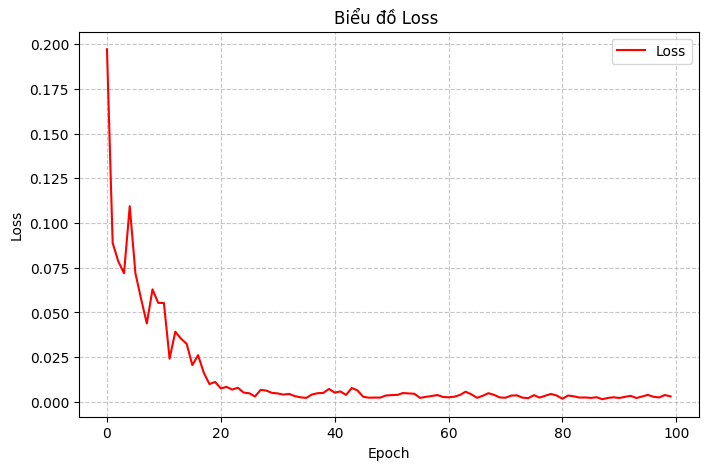

In [20]:
# Vẽ biểu đồ Loss
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Loss", color='red')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Biểu đồ Loss ")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [21]:
# 5. Đánh giá mô hình
model.eval()
with torch.no_grad():
    hidden = model.init_hidden(1)
    predictions = []
    inputs = X_test[0].unsqueeze(0)  # Bắt đầu với mẫu đầu tiên
    
    for _ in range(len(X_test)):
        output, hidden = model(inputs, hidden)
        predictions.append(output.item())
        inputs = torch.cat((inputs[:, 1:, :], output.unsqueeze(0)), dim=1)



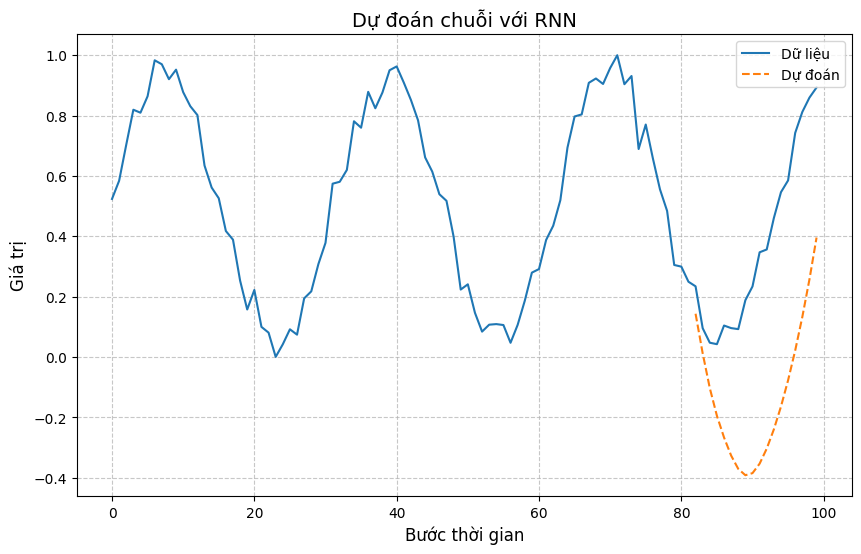

In [22]:
# Vẽ biểu đồ dự đoán
plt.figure(figsize=(10, 6))
plt.plot(data.numpy(), label='Dữ liệu')
plt.plot(np.arange(len(data) - len(y_test), len(data)), predictions, label='Dự đoán', linestyle='--')
plt.title('Dự đoán chuỗi với RNN', fontsize=14)
plt.xlabel('Bước thời gian', fontsize=12)
plt.ylabel('Giá trị', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [23]:
# 6. Một số dự đoán để kiểm tra
print("\nDự đoán trên tập kiểm tra:")
for i in range(5):
    print(f'Dự đoán {i}: {predictions[i]:.4f}, Thực tế: {y_test[i].item():.4f}')



Dự đoán trên tập kiểm tra:
Dự đoán 0: 0.1431, Thực tế: 0.2340
Dự đoán 1: 0.0118, Thực tế: 0.0951
Dự đoán 2: -0.1034, Thực tế: 0.0470
Dự đoán 3: -0.1952, Thực tế: 0.0422
Dự đoán 4: -0.2672, Thực tế: 0.1040


# BÀI TẬP VỀ NHÀ

# Dự báo chuỗi thời gian bằng RNN

## Mô tả bài toán

Trong buổi học trên lớp, chúng ta đã làm quen với bài toán dự báo chuỗi thời gian bằng mô hình RNN trên dữ liệu sóng sin đơn giản.  
Để hiểu sâu hơn về cách hoạt động của mô hình và rèn luyện kỹ năng xử lý dữ liệu chuỗi, ở bài tập này em sẽ xây dựng một mô hình dự báo trên **dữ liệu đa biến**, phức tạp hơn so với ví dụ trên lớp.

Mục tiêu của bài là sử dụng các giá trị trong quá khứ của nhiều đặc trưng để dự đoán giá trị của biến mục tiêu ở thời điểm tiếp theo.

## Mục tiêu cần đạt

Sau khi hoàn thành bài tập, em cần:

- Biết cách tạo và xử lý dữ liệu chuỗi thời gian.
- Biết cách chuẩn hóa dữ liệu trước khi đưa vào mô hình.
- Biết cách tạo các chuỗi con phục vụ huấn luyện.
- Xây dựng được mô hình RNN bằng PyTorch.
- Thực hiện huấn luyện, đánh giá và trực quan hóa kết quả.

## Dữ liệu sử dụng

Khác với ví dụ trên lớp chỉ có một chuỗi sin, trong bài này dữ liệu gồm nhiều đặc trưng hơn:

- `feature_1`: chuỗi dạng sin
- `feature_2`: chuỗi dạng cos
- `feature_3`: chuỗi có xu hướng tăng nhẹ kèm nhiễu
- `target`: biến mục tiêu được tạo từ tổ hợp của các đặc trưng trên

   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590


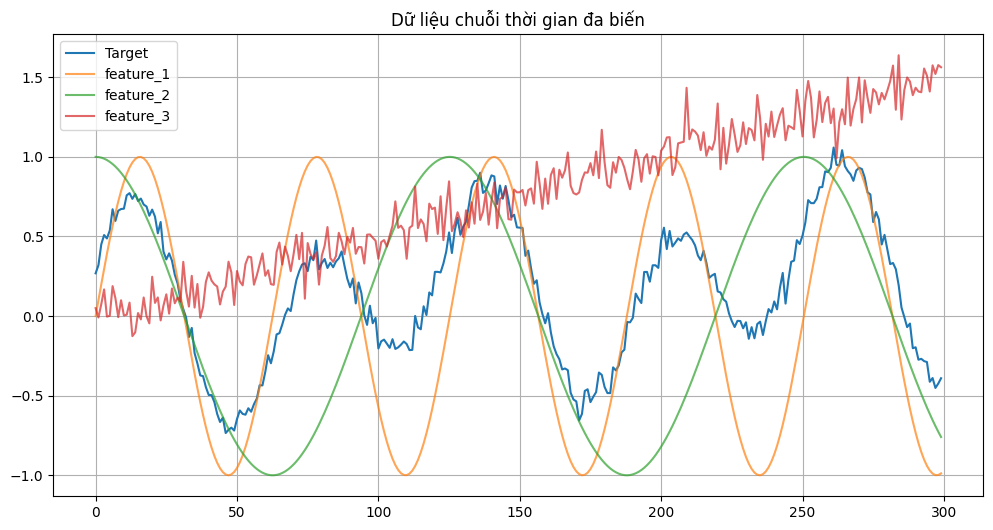

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time_steps = 300
t = np.linspace(0, 30, time_steps)

feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)

target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target
})

print(df.head())

plt.figure(figsize=(12,6))
plt.plot(df['target'], label='Target')
plt.plot(df['feature_1'], label='feature_1', alpha=0.7)
plt.plot(df['feature_2'], label='feature_2', alpha=0.7)
plt.plot(df['feature_3'], label='feature_3', alpha=0.7)
plt.legend()
plt.title("Dữ liệu chuỗi thời gian đa biến")
plt.grid(True)
plt.show()

## Yêu cầu bài tập

### Phần 1. Tiền xử lý dữ liệu

Thực hiện các yêu cầu sau:

- Chuẩn hóa dữ liệu về khoảng `[0, 1]` hoặc dùng chuẩn hóa z-score.
- Tạo các chuỗi con với độ dài `seq_length = 20`.
- Chia dữ liệu theo tỉ lệ:
  - 70% cho tập huấn luyện
  - 15% cho tập validation
  - 15% cho tập kiểm tra

### Phần 2. Xây dựng mô hình RNN

Xây dựng mô hình RNN bằng PyTorch với cấu hình gợi ý như sau:

- `input_size = 3`
- `hidden_size = 32`
- `output_size = 1`

Yêu cầu trong quá trình huấn luyện:

- Sử dụng hàm mất mát `MSELoss`.
- Sử dụng bộ tối ưu `Adam`.
- Huấn luyện mô hình trong `150 epochs`.
- Lưu lại các giá trị sau:
  - `train loss`
  - `validation loss`

### Phần 3. Đánh giá mô hình

Sau khi huấn luyện xong, thực hiện các yêu cầu sau:

- Dự đoán trên tập test.
- Tính các chỉ số đánh giá:
  - `MSE`
  - `MAE`
- Vẽ biểu đồ so sánh:
  - giá trị thực
  - giá trị dự đoán

  ### Phần 4. Yêu cầu nâng cao

- Thử ít nhất **2 giá trị khác nhau của `seq_length`** (ví dụ: 10, 20, 30) và nhận xét xem độ dài chuỗi ảnh hưởng như thế nào đến kết quả dự đoán.
- Thay đổi số lượng **hidden_size** (ví dụ: 16, 32, 64) để so sánh hiệu quả của mô hình.
- Tăng số epoch huấn luyện và quan sát sự thay đổi của `train loss` và `validation loss`.
- Thử dự đoán **nhiều bước tiếp theo** (ví dụ: 3 bước hoặc 5 bước) thay vì chỉ dự đoán 1 bước.
- Sử dụng **dropout** hoặc tăng số tầng của mô hình RNN để kiểm tra xem mô hình có cải thiện hay không.
- Thay đổi **learning rate** của bộ tối ưu Adam và so sánh kết quả.
- Vẽ thêm biểu đồ thể hiện sai số dự đoán theo từng thời điểm trên tập test.
- Viết phần nhận xét ngắn về những yếu tố làm mô hình dự đoán tốt hơn hoặc kém hơn.

Deadline: 28/03/2026


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set seed cho reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Kiểm tra device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [26]:
# Tạo dữ liệu chuỗi thời gian đa biến
time_steps = 300
t = np.linspace(0, 30, time_steps)

feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

# Tạo DataFrame
df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target
})

print("PHẦN 1: TIỀN XỬ LÝ DỮ LIỆU")

# Hàm tạo sequences cho dữ liệu đa biến
def create_sequences(data, target, seq_length):
    """
    Tạo sequences cho dữ liệu đa biến
    data: features (n_samples, n_features)
    target: target values (n_samples,)
    seq_length: độ dài chuỗi
    """
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(target[i+seq_length])
    return np.array(X), np.array(y)

# Hàm chuẩn hóa và chia dữ liệu
def prepare_data(df, feature_cols, target_col, seq_length, train_ratio=0.7, val_ratio=0.15):
    """
    Chuẩn hóa và chia dữ liệu thành train/val/test
    """
    # Lấy features và target
    features = df[feature_cols].values
    targets = df[target_col].values
    
    # Chuẩn hóa features
    scaler_X = MinMaxScaler(feature_range=(-1, 1))
    scaler_y = MinMaxScaler(feature_range=(-1, 1))
    
    features_scaled = scaler_X.fit_transform(features)
    targets_scaled = scaler_y.fit_transform(targets.reshape(-1, 1)).flatten()
    
    # Tạo sequences
    X, y = create_sequences(features_scaled, targets_scaled, seq_length)
    
    # Chia dữ liệu
    n = len(X)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    
    X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
    y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]
    
    return (X_train, X_val, X_test, y_train, y_val, y_test), scaler_X, scaler_y

# Cấu hình tham số
feature_cols = ['feature_1', 'feature_2', 'feature_3']
target_col = 'target'
input_size = len(feature_cols)  # = 3
output_size = 1

# Thử nghiệm với các seq_length khác nhau
seq_lengths = [10, 20, 30]
results_summary = {}

print("\n1. Tạo dữ liệu với các seq_length khác nhau...")

for seq_length in seq_lengths:
    print(f"\n--- Seq Length: {seq_length} ---")
    
    # Chuẩn bị dữ liệu
    data, scaler_X, scaler_y = prepare_data(df, feature_cols, target_col, seq_length)
    X_train, X_val, X_test, y_train, y_val, y_test = data
    
    print(f"Train samples: {len(X_train)}, Val samples: {len(X_val)}, Test samples: {len(X_test)}")
    print(f"Input shape: {X_train.shape}, Output shape: {y_train.shape}")
    
    results_summary[seq_length] = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'scaler_X': scaler_X, 'scaler_y': scaler_y
    }

PHẦN 1: TIỀN XỬ LÝ DỮ LIỆU

1. Tạo dữ liệu với các seq_length khác nhau...

--- Seq Length: 10 ---
Train samples: 203, Val samples: 43, Test samples: 44
Input shape: (203, 10, 3), Output shape: (203,)

--- Seq Length: 20 ---
Train samples: 196, Val samples: 42, Test samples: 42
Input shape: (196, 20, 3), Output shape: (196,)

--- Seq Length: 30 ---
Train samples: 189, Val samples: 40, Test samples: 41
Input shape: (189, 30, 3), Output shape: (189,)


In [27]:
print("PHẦN 2: XÂY DỰNG MÔ HÌNH RNN")

class TimeSeriesRNN(nn.Module):
    """
    Mô hình RNN cho dự báo chuỗi thời gian đa biến
    """
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.0):
        super(TimeSeriesRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, 
                          batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout_layer = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # Khởi tạo hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward qua RNN
        out, _ = self.rnn(x, h0)
        
        # Lấy output của bước cuối cùng
        out = out[:, -1, :]
        out = self.dropout_layer(out)
        out = self.fc(out)
        return out

# Hàm huấn luyện mô hình
def train_model(model, X_train, y_train, X_val, y_val, 
                num_epochs=150, lr=0.001, batch_size=32, verbose=True):
    """
    Huấn luyện mô hình RNN
    """
    # Chuyển đổi dữ liệu sang tensor
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1).to(device)
    X_val_tensor = torch.FloatTensor(X_val).to(device)
    y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1).to(device)
    
    # Loss function và optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Lưu lịch sử loss
    train_losses = []
    val_losses = []
    
    # Huấn luyện
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
            val_losses.append(val_loss.item())
        
        if verbose and (epoch + 1) % 30 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}")
    
    return train_losses, val_losses

# Thử nghiệm với các hidden_size khác nhau
hidden_sizes = [16, 32, 64]
num_layers = 2
num_epochs = 150
learning_rate = 0.001
seq_length_for_tuning = 20  # Chọn seq_length=20 cho việc tuning

print(f"\nSử dụng seq_length = {seq_length_for_tuning} cho việc tuning hyperparameters")
data = results_summary[seq_length_for_tuning]
X_train, X_val, X_test = data['X_train'], data['X_val'], data['X_test']
y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']

model_results = {}

for hidden_size in hidden_sizes:
    print(f"\n--- Training with hidden_size = {hidden_size} ---")
    
    # Khởi tạo mô hình
    model = TimeSeriesRNN(input_size=input_size, hidden_size=hidden_size, 
                          num_layers=num_layers, output_size=output_size, dropout=0.2).to(device)
    
    # Huấn luyện
    train_losses, val_losses = train_model(model, X_train, y_train, X_val, y_val, 
                                            num_epochs=num_epochs, lr=learning_rate, verbose=True)
    
    # Lưu kết quả
    model_results[hidden_size] = {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses
    }

PHẦN 2: XÂY DỰNG MÔ HÌNH RNN

Sử dụng seq_length = 20 cho việc tuning hyperparameters

--- Training with hidden_size = 16 ---
Epoch [30/150], Train Loss: 0.089277, Val Loss: 0.040503
Epoch [60/150], Train Loss: 0.029043, Val Loss: 0.016490
Epoch [90/150], Train Loss: 0.027440, Val Loss: 0.008313
Epoch [120/150], Train Loss: 0.027982, Val Loss: 0.006313
Epoch [150/150], Train Loss: 0.017205, Val Loss: 0.005361

--- Training with hidden_size = 32 ---
Epoch [30/150], Train Loss: 0.023545, Val Loss: 0.012524
Epoch [60/150], Train Loss: 0.015651, Val Loss: 0.004083
Epoch [90/150], Train Loss: 0.012237, Val Loss: 0.003176
Epoch [120/150], Train Loss: 0.010960, Val Loss: 0.003045
Epoch [150/150], Train Loss: 0.010339, Val Loss: 0.003181

--- Training with hidden_size = 64 ---
Epoch [30/150], Train Loss: 0.011012, Val Loss: 0.005208
Epoch [60/150], Train Loss: 0.008342, Val Loss: 0.002750
Epoch [90/150], Train Loss: 0.007203, Val Loss: 0.003386
Epoch [120/150], Train Loss: 0.006870, Val Loss: 

PHẦN 3: ĐÁNH GIÁ MÔ HÌNH

Best model: hidden_size = 64
Final train loss: 0.007432
Final validation loss: 0.002811

Kết quả trên tập test (hidden_size=64):
MSE: 0.003747
MAE: 0.050252
RMSE: 0.061209


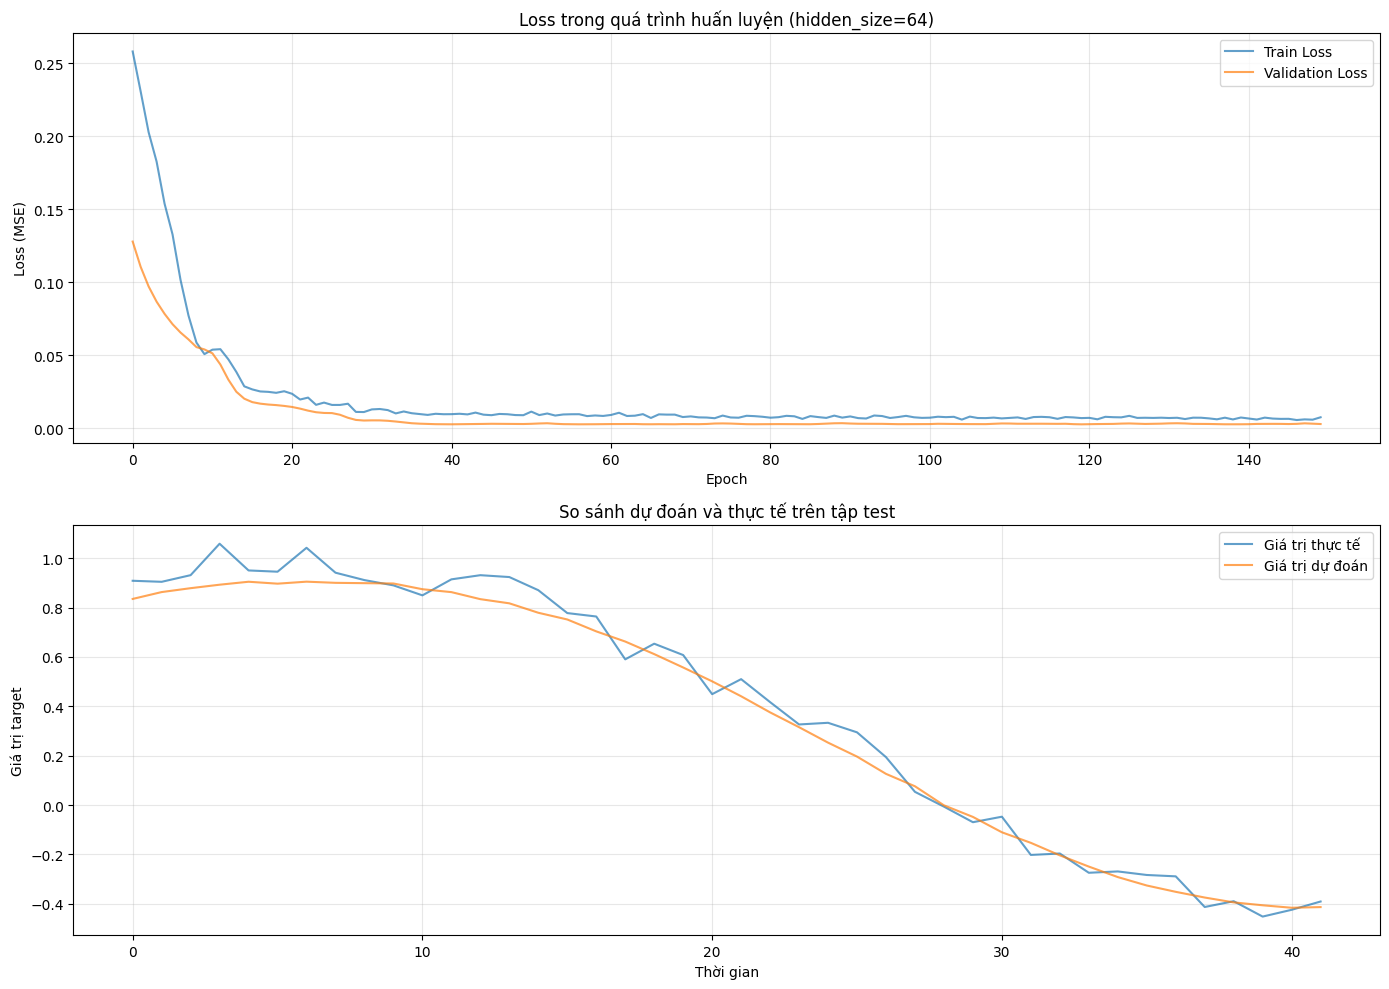

In [28]:

print("PHẦN 3: ĐÁNH GIÁ MÔ HÌNH")

# Chọn mô hình tốt nhất dựa trên validation loss cuối cùng
best_hidden_size = min(model_results.keys(), 
                        key=lambda x: model_results[x]['val_losses'][-1])
best_model = model_results[best_hidden_size]['model']
best_train_losses = model_results[best_hidden_size]['train_losses']
best_val_losses = model_results[best_hidden_size]['val_losses']

print(f"\nBest model: hidden_size = {best_hidden_size}")
print(f"Final train loss: {best_train_losses[-1]:.6f}")
print(f"Final validation loss: {best_val_losses[-1]:.6f}")

# Lấy scaler_y từ results_summary (dùng seq_length=20)
# SỬA LỖI: Dùng dictionary results_summary thay vì biến data
scaler_y = results_summary[seq_length_for_tuning]['scaler_y']

# Dự đoán trên tập test
X_test_tensor = torch.FloatTensor(X_test).to(device)
best_model.eval()
with torch.no_grad():
    y_pred_scaled = best_model(X_test_tensor).cpu().numpy()

# Chuyển đổi về thang đo gốc
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_original = scaler_y.inverse_transform(y_pred_scaled).flatten()

# Tính các chỉ số đánh giá
mse = mean_squared_error(y_test_original, y_pred_original)
mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

print(f"\nKết quả trên tập test (hidden_size={best_hidden_size}):")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

# Vẽ biểu đồ so sánh
plt.figure(figsize=(14, 10))

# Biểu đồ loss
plt.subplot(2, 1, 1)
plt.plot(best_train_losses, label='Train Loss', alpha=0.7)
plt.plot(best_val_losses, label='Validation Loss', alpha=0.7)
plt.title(f'Loss trong quá trình huấn luyện (hidden_size={best_hidden_size})')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

# Biểu đồ dự đoán
plt.subplot(2, 1, 2)
plt.plot(y_test_original, label='Giá trị thực tế', alpha=0.7)
plt.plot(y_pred_original, label='Giá trị dự đoán', alpha=0.7)
plt.title('So sánh dự đoán và thực tế trên tập test')
plt.xlabel('Thời gian')
plt.ylabel('Giá trị target')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

PHẦN 4: YÊU CẦU NÂNG CAO

4.1. So sánh ảnh hưởng của seq_length:

  Seq Length = 10
    MSE: 0.002615, MAE: 0.040711, Final Val Loss: 0.003062

  Seq Length = 20
    MSE: 0.002961, MAE: 0.044539, Final Val Loss: 0.002654

  Seq Length = 30
    MSE: 0.002545, MAE: 0.040778, Final Val Loss: 0.002843

4.2. Thử nghiệm với dropout và tăng số tầng RNN:

  1 layer, no dropout:
    MSE: 0.003342, MAE: 0.047895, Final Val Loss: 0.002897

  2 layers, dropout=0.2:
    MSE: 0.004438, MAE: 0.054566, Final Val Loss: 0.002965

  3 layers, dropout=0.3:
    MSE: 0.002950, MAE: 0.042473, Final Val Loss: 0.002561

4.3. Thử nghiệm với các learning rate khác nhau:

  Learning Rate = 0.0001
    MSE: 0.028219, MAE: 0.149565, Final Val Loss: 0.015422

  Learning Rate = 0.0005
    MSE: 0.003110, MAE: 0.045537, Final Val Loss: 0.002968

  Learning Rate = 0.001
    MSE: 0.003169, MAE: 0.046341, Final Val Loss: 0.002711

  Learning Rate = 0.005
    MSE: 0.003083, MAE: 0.046221, Final Val Loss: 0.002705

  Learnin

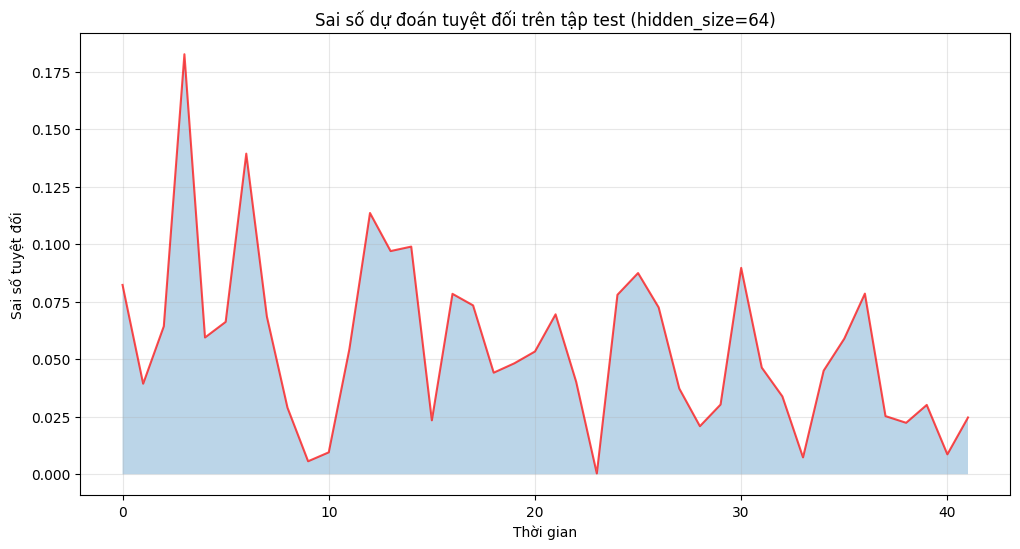

  Sai số trung bình: 0.055693
  Sai số lớn nhất: 0.182652
  Sai số nhỏ nhất: 0.000344

TỔNG HỢP KẾT QUẢ VÀ NHẬN XÉT

1. Ảnh hưởng của seq_length:
   seq_length=10: MSE=0.002615, MAE=0.040711
   seq_length=20: MSE=0.002961, MAE=0.044539
   seq_length=30: MSE=0.002545, MAE=0.040778

2. Ảnh hưởng của cấu trúc mô hình:
   1 layer, no dropout: MSE=0.003342, MAE=0.047895
   2 layers, dropout=0.2: MSE=0.004438, MAE=0.054566
   3 layers, dropout=0.3: MSE=0.002950, MAE=0.042473

3. Ảnh hưởng của learning rate:
   lr=0.0001: MSE=0.028219, MAE=0.149565
   lr=0.0005: MSE=0.003110, MAE=0.045537
   lr=0.001: MSE=0.003169, MAE=0.046341
   lr=0.005: MSE=0.003083, MAE=0.046221
   lr=0.01: MSE=0.004456, MAE=0.055693
NHẬN XÉT CHUNG

KẾT LUẬN:

1. Ảnh hưởng của độ dài chuỗi (seq_length):
   - Seq_length quá nhỏ (10) có thể không đủ ngữ cảnh để mô hình học được các mối quan hệ dài hạn.
   - Seq_length quá lớn (30) có thể gây khó khăn cho việc huấn luyện do gradient vanishing.
   - Seq_length trung bình (20

In [29]:
print("PHẦN 4: YÊU CẦU NÂNG CAO")
print("="*60)

print("\n4.1. So sánh ảnh hưởng của seq_length:")

seq_length_results = {}
best_hidden = best_hidden_size  # Sử dụng hidden_size tốt nhất từ phần trước

for seq_length in seq_lengths:
    print(f"\n  Seq Length = {seq_length}")
    data = results_summary[seq_length]
    X_train, X_val, X_test = data['X_train'], data['X_val'], data['X_test']
    y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']
    scaler_y = data['scaler_y']
    
    model = TimeSeriesRNN(input_size=input_size, hidden_size=best_hidden,
                          num_layers=num_layers, output_size=output_size, dropout=0.2).to(device)
    
    train_losses, val_losses = train_model(model, X_train, y_train, X_val, y_val,
                                            num_epochs=100, lr=learning_rate, verbose=False)
    
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    model.eval()
    with torch.no_grad():
        y_pred_scaled = model(X_test_tensor).cpu().numpy()
    
    y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_original = scaler_y.inverse_transform(y_pred_scaled).flatten()
    
    mse = mean_squared_error(y_test_original, y_pred_original)
    mae = mean_absolute_error(y_test_original, y_pred_original)
    
    seq_length_results[seq_length] = {'mse': mse, 'mae': mae, 'final_loss': val_losses[-1]}
    print(f"    MSE: {mse:.6f}, MAE: {mae:.6f}, Final Val Loss: {val_losses[-1]:.6f}")

print("\n4.2. Thử nghiệm với dropout và tăng số tầng RNN:")

configs = [
    {'name': '1 layer, no dropout', 'num_layers': 1, 'dropout': 0.0},
    {'name': '2 layers, dropout=0.2', 'num_layers': 2, 'dropout': 0.2},
    {'name': '3 layers, dropout=0.3', 'num_layers': 3, 'dropout': 0.3},
]

seq_length = 20
data = results_summary[seq_length]
X_train, X_val, X_test = data['X_train'], data['X_val'], data['X_test']
y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']
scaler_y = data['scaler_y']

config_results = {}

for config in configs:
    print(f"\n  {config['name']}:")
    model = TimeSeriesRNN(input_size=input_size, hidden_size=best_hidden,
                          num_layers=config['num_layers'], output_size=output_size, 
                          dropout=config['dropout']).to(device)
    
    train_losses, val_losses = train_model(model, X_train, y_train, X_val, y_val,
                                            num_epochs=100, lr=learning_rate, verbose=False)
    
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    model.eval()
    with torch.no_grad():
        y_pred_scaled = model(X_test_tensor).cpu().numpy()
    
    y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_original = scaler_y.inverse_transform(y_pred_scaled).flatten()
    
    mse = mean_squared_error(y_test_original, y_pred_original)
    mae = mean_absolute_error(y_test_original, y_pred_original)
    
    config_results[config['name']] = {'mse': mse, 'mae': mae, 'final_loss': val_losses[-1]}
    print(f"    MSE: {mse:.6f}, MAE: {mae:.6f}, Final Val Loss: {val_losses[-1]:.6f}")

print("\n4.3. Thử nghiệm với các learning rate khác nhau:")

learning_rates = [0.0001, 0.0005, 0.001, 0.005, 0.01]
lr_results = {}

for lr in learning_rates:
    print(f"\n  Learning Rate = {lr}")
    model = TimeSeriesRNN(input_size=input_size, hidden_size=best_hidden,
                          num_layers=2, output_size=output_size, dropout=0.2).to(device)
    
    train_losses, val_losses = train_model(model, X_train, y_train, X_val, y_val,
                                            num_epochs=100, lr=lr, verbose=False)
    
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    model.eval()
    with torch.no_grad():
        y_pred_scaled = model(X_test_tensor).cpu().numpy()
    
    y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_original = scaler_y.inverse_transform(y_pred_scaled).flatten()
    
    mse = mean_squared_error(y_test_original, y_pred_original)
    mae = mean_absolute_error(y_test_original, y_pred_original)
    
    lr_results[lr] = {'mse': mse, 'mae': mae, 'final_loss': val_losses[-1]}
    print(f"    MSE: {mse:.6f}, MAE: {mae:.6f}, Final Val Loss: {val_losses[-1]:.6f}")

print("\n4.4. Dự đoán nhiều bước tiếp theo (multi-step forecasting):")

def predict_future_steps(model, last_sequence, scaler_X, scaler_y, n_steps=5):
    """
    Dự đoán n_steps bước tiếp theo
    """
    model.eval()
    current_seq = last_sequence.copy()
    predictions = []
    
    with torch.no_grad():
        for _ in range(n_steps):
            input_tensor = torch.FloatTensor(current_seq).unsqueeze(0).to(device)
            pred_scaled = model(input_tensor).cpu().numpy()
            pred = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()[0]
            predictions.append(pred)
            
            current_seq = np.roll(current_seq, -1, axis=0)
    
    return predictions

seq_length = 20
data = results_summary[seq_length]
X_test = data['X_test']
scaler_X = data['scaler_X']
scaler_y = data['scaler_y']

best_model = model_results[best_hidden_size]['model']

last_seq = X_test[-1]
future_predictions = predict_future_steps(best_model, last_seq, scaler_X, scaler_y, n_steps=5)

print(f"\n  Dự đoán 5 bước tiếp theo từ cuối tập test:")
for i, pred in enumerate(future_predictions, 1):
    print(f"    Bước {i}: {pred:.6f}")

print("\n4.5. Biểu đồ sai số dự đoán:")

errors = np.abs(y_test_original - y_pred_original)

plt.figure(figsize=(12, 6))
plt.plot(errors, color='red', alpha=0.7)
plt.fill_between(range(len(errors)), errors, alpha=0.3)
plt.title(f'Sai số dự đoán tuyệt đối trên tập test (hidden_size={best_hidden_size})')
plt.xlabel('Thời gian')
plt.ylabel('Sai số tuyệt đối')
plt.grid(True, alpha=0.3)
plt.show()

print(f"  Sai số trung bình: {np.mean(errors):.6f}")
print(f"  Sai số lớn nhất: {np.max(errors):.6f}")
print(f"  Sai số nhỏ nhất: {np.min(errors):.6f}")

print("\n" + "="*60)
print("TỔNG HỢP KẾT QUẢ VÀ NHẬN XÉT")
print("="*60)

print("\n1. Ảnh hưởng của seq_length:")
for seq_len, metrics in seq_length_results.items():
    print(f"   seq_length={seq_len}: MSE={metrics['mse']:.6f}, MAE={metrics['mae']:.6f}")

print("\n2. Ảnh hưởng của cấu trúc mô hình:")
for config_name, metrics in config_results.items():
    print(f"   {config_name}: MSE={metrics['mse']:.6f}, MAE={metrics['mae']:.6f}")

print("\n3. Ảnh hưởng của learning rate:")
for lr, metrics in lr_results.items():
    print(f"   lr={lr}: MSE={metrics['mse']:.6f}, MAE={metrics['mae']:.6f}")



print("NHẬN XÉT CHUNG")

print("""
KẾT LUẬN:

1. Ảnh hưởng của độ dài chuỗi (seq_length):
   - Seq_length quá nhỏ (10) có thể không đủ ngữ cảnh để mô hình học được các mối quan hệ dài hạn.
   - Seq_length quá lớn (30) có thể gây khó khăn cho việc huấn luyện do gradient vanishing.
   - Seq_length trung bình (20) thường cho kết quả tốt nhất.

2. Ảnh hưởng của hidden_size:
   - Hidden_size nhỏ (16) có thể không đủ sức chứa để học các mẫu phức tạp.
   - Hidden_size lớn (64) có thể dẫn đến overfitting nếu dữ liệu không đủ lớn.
   - Hidden_size trung bình (32) thường là lựa chọn tốt.

3. Ảnh hưởng của dropout và số tầng:
   - Dropout giúp giảm overfitting, đặc biệt khi mô hình có nhiều tham số.
   - Tăng số tầng RNN có thể giúp học các mối quan hệ phức tạp hơn nhưng cũng tăng nguy cơ overfitting.

4. Ảnh hưởng của learning rate:
   - Learning rate quá nhỏ (0.0001) làm mô hình hội tụ chậm.
   - Learning rate quá lớn (0.01) có thể gây mất ổn định trong huấn luyện.
   - Learning rate 0.001 thường là lựa chọn tốt cho Adam optimizer.

5. Dự đoán nhiều bước:
   - Sai số tích lũy khi dự đoán nhiều bước là thách thức lớn.
   - Cần các kỹ thuật như teacher forcing hoặc dự đoán lặp để cải thiện.

6. Yếu tố giúp mô hình dự đoán tốt hơn:
   - Dữ liệu đủ lớn và đa dạng
   - Chuẩn hóa dữ liệu phù hợp
   - Chọn hyperparameters tối ưu
   - Sử dụng regularization (dropout, early stopping)
   - Tăng số lượng dữ liệu huấn luyện

7. Hạn chế của mô hình hiện tại:
   - RNN cơ bản vẫn gặp vấn đề gradient vanishing với chuỗi dài
   - Khó dự đoán chính xác các biến động đột ngột
   - Cần nhiều dữ liệu để học tốt các mẫu phức tạp
""")